This is a notebook exploring the 2022 Intracranial hemorrhage Segmentation Challenge on Non-Contrast Head CFT ([INSTANCE 2022](https://instance.grand-challenge.org/)) dataset as part of **Aim 1.1: Characterizing Real ICH**

Long term goal: create CSV/XLSX with data ID, hemorrhage volume, and hemorrhage type.

To begin, set some directory variables (may change in the future).

In [1]:
dataset_path = '/gpfs_projects/jayse.weaver/INSTANCE2022_Dataset/'

print('Contents of main dataset directory')
!ls $dataset_path
print('Contents of evaluation')
!ls $dataset_path/evaluation
print('Contents of train')
!ls $dataset_path/train
print('Contents of train/data')
!ls $dataset_path/train/data

Contents of main dataset directory
evaluation  train
Contents of evaluation
101.nii.gz  106.nii.gz	111.nii.gz  116.nii.gz	121.nii.gz  126.nii.gz
102.nii.gz  107.nii.gz	112.nii.gz  117.nii.gz	122.nii.gz  127.nii.gz
103.nii.gz  108.nii.gz	113.nii.gz  118.nii.gz	123.nii.gz  128.nii.gz
104.nii.gz  109.nii.gz	114.nii.gz  119.nii.gz	124.nii.gz  129.nii.gz
105.nii.gz  110.nii.gz	115.nii.gz  120.nii.gz	125.nii.gz  130.nii.gz
Contents of train
data  label
Contents of train/data
001.nii.gz  018.nii.gz	035.nii.gz  052.nii.gz	069.nii.gz  086.nii.gz
002.nii.gz  019.nii.gz	036.nii.gz  053.nii.gz	070.nii.gz  087.nii.gz
003.nii.gz  020.nii.gz	037.nii.gz  054.nii.gz	071.nii.gz  088.nii.gz
004.nii.gz  021.nii.gz	038.nii.gz  055.nii.gz	072.nii.gz  089.nii.gz
005.nii.gz  022.nii.gz	039.nii.gz  056.nii.gz	073.nii.gz  090.nii.gz
006.nii.gz  023.nii.gz	040.nii.gz  057.nii.gz	074.nii.gz  091.nii.gz
007.nii.gz  024.nii.gz	041.nii.gz  058.nii.gz	075.nii.gz  092.nii.gz
008.nii.gz  025.nii.gz	042.nii.gz  059.nii.

The "Evaluation" dataset has 30 cases but no ground truth labels, and is less useful to us, while "Train" has 100 segmentations and ground truth segmentation volumes.

In [2]:
import os
import pandas as pd

# initialize empty dataframe
df = pd.DataFrame(columns=['Data_ID', 'Volume_[mL]', 'Mean_HU', 'Median_HU'])
print(df)

label_names = sorted(os.listdir(dataset_path + 'train/label'))
for idx, x in enumerate(label_names):
    label_names[idx] = x.split(".")[0] # remove nifti zip suffix

df.iloc[:, 0] = label_names
print(df)

Empty DataFrame
Columns: [Data_ID, Volume_[mL], Mean_HU, Median_HU]
Index: []
   Data_ID Volume_[mL] Mean_HU Median_HU
0      001         NaN     NaN       NaN
1      002         NaN     NaN       NaN
2      003         NaN     NaN       NaN
3      004         NaN     NaN       NaN
4      005         NaN     NaN       NaN
..     ...         ...     ...       ...
95     096         NaN     NaN       NaN
96     097         NaN     NaN       NaN
97     098         NaN     NaN       NaN
98     099         NaN     NaN       NaN
99     100         NaN     NaN       NaN

[100 rows x 4 columns]


Next, load the segmentation masks with nibabel. Using the voxel dimensions in the header, convert the number of pixels to volume size in mL/cc.

Additionally, we can use the segmentation mask to calculate the mean and median HU within the hemorrhage area.

In [3]:
import numpy as np
import nibabel as nib
from utils import scrollview
import sys
import matplotlib.pyplot as plt

for idx, ID in enumerate(label_names):
    img = nib.load(dataset_path + 'train/label/' + ID + '.nii.gz')
    [dx, dy, dz] = img.header['pixdim'][1:4] # extract voxel dimensions from NifTI header (in mm)
    hemorrhage_mask = img.get_fdata()
    hemorrhage_volume = (len(np.argwhere(hemorrhage_mask == 1)))*((dx*dy*dz)/1000)
    df.iloc[idx, 1] = hemorrhage_volume

    CTimg = nib.load(dataset_path + 'train/data/' + ID + '.nii.gz')
    CTarray = CTimg.get_fdata()

    lesion_only = np.multiply(CTarray, hemorrhage_mask)

    mean_HU = np.mean(lesion_only[np.nonzero(hemorrhage_mask)])
    df.iloc[idx, 2] = mean_HU

    median_HU = np.median(lesion_only[np.nonzero(hemorrhage_mask)])
    df.iloc[idx, 3] = median_HU

print(df)

   Data_ID Volume_[mL]    Mean_HU Median_HU
0      001    0.196927  45.929293      46.0
1      002     6.70433  46.074858      45.0
2      003    2.834797  39.917157      40.0
3      004    7.653935  58.258968      58.0
4      005     1.69158  32.845666      33.0
..     ...         ...        ...       ...
95     096    1.516378  58.966154      58.0
96     097   23.785685  50.408703      51.0
97     098   41.996239  28.110875      23.0
98     099   65.180809  58.082387      59.0
99     100  109.947159  61.418694      63.0

[100 rows x 4 columns]


Perform some basic plotting to show variability in hemorrhage volume

Text(0.5, 0, 'Data ID')

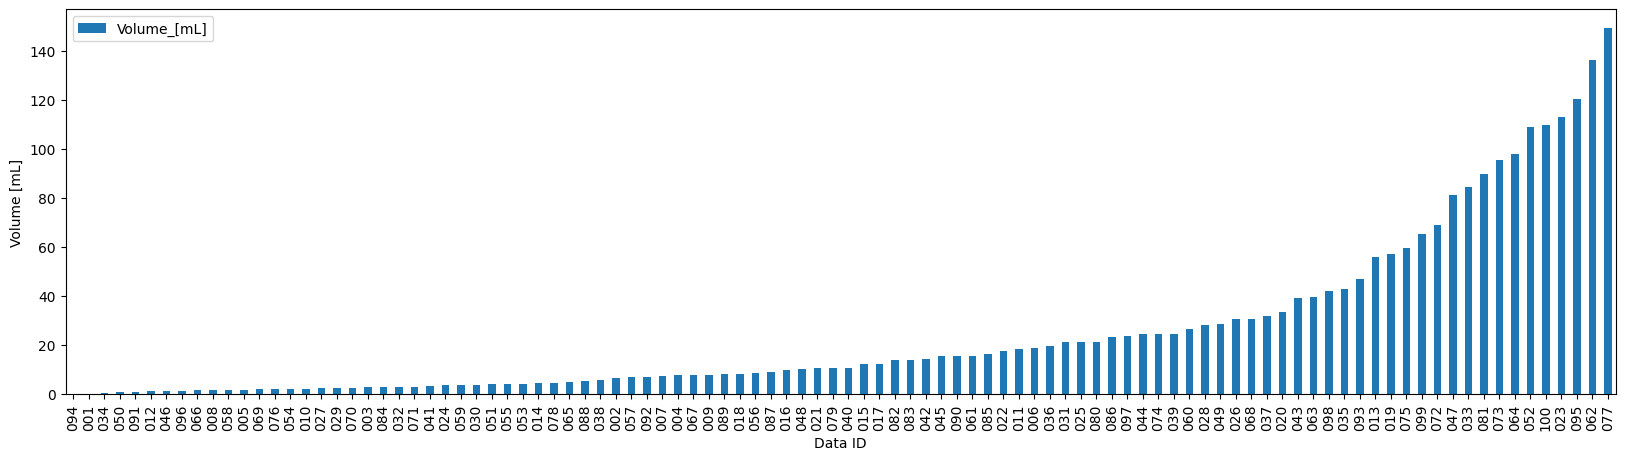

In [4]:
sorted_df = df.sort_values(by=['Volume_[mL]'])
ax = sorted_df.plot(x='Data_ID', y='Volume_[mL]', kind="bar", figsize=(20, 5))
ax.set_ylabel('Volume [mL]')
ax.set_xlabel('Data ID')

Text(0.5, 0, 'Data ID')

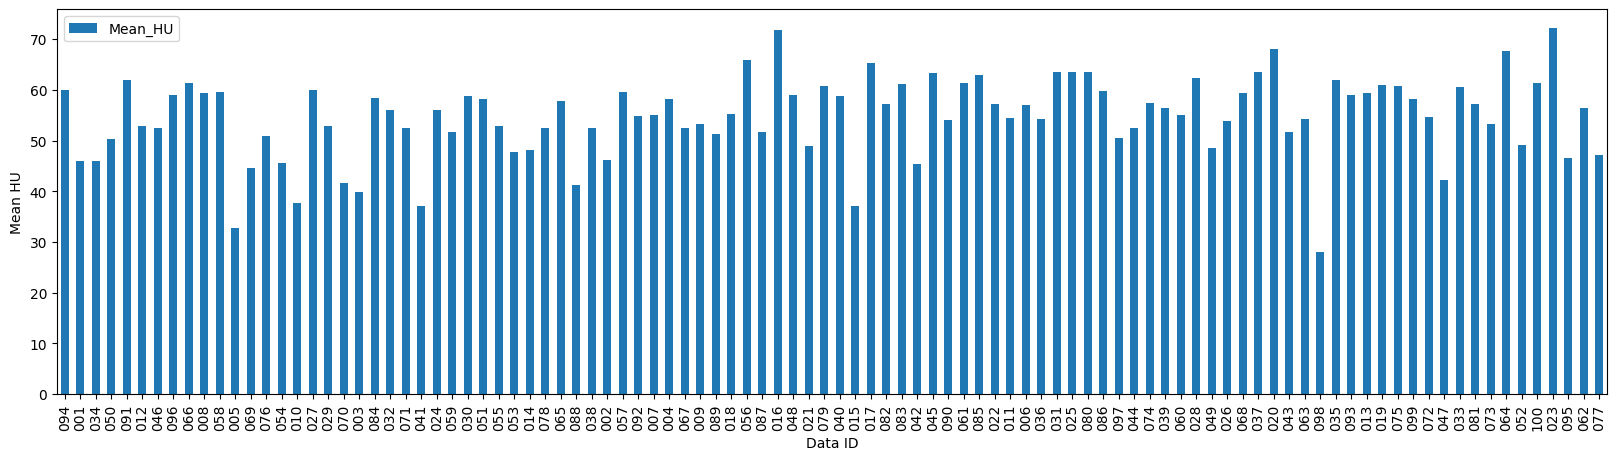

In [5]:
ax = sorted_df.plot(x='Data_ID', y='Mean_HU', kind='bar', figsize=(20, 5))
ax.set_ylabel('Mean HU')
ax.set_xlabel('Data ID')

Text(0.5, 0, 'Volume [mL]')

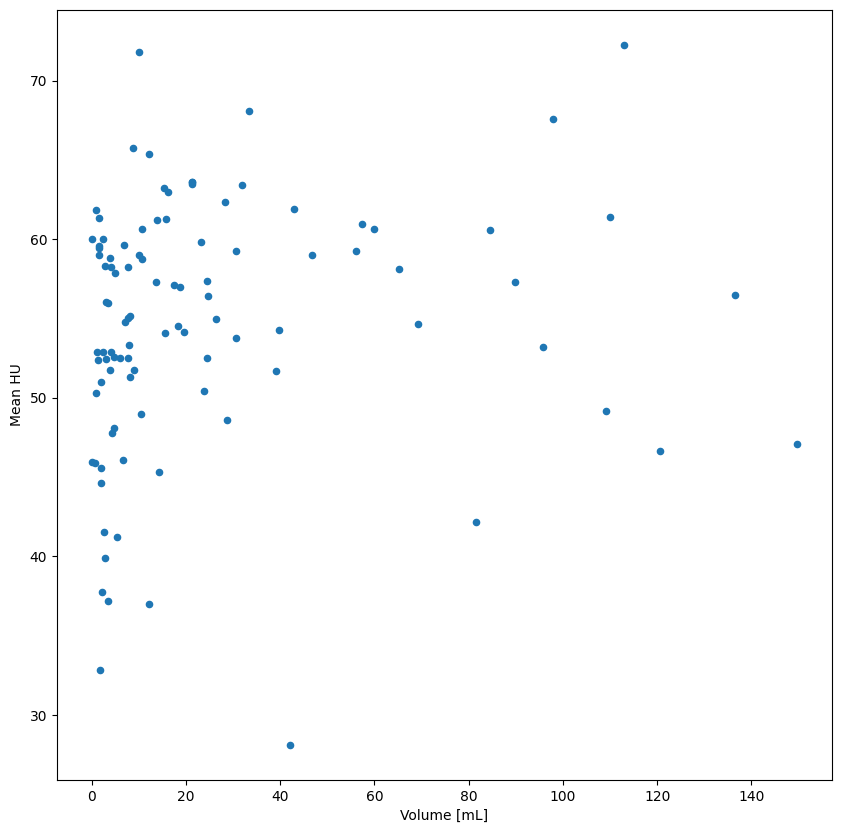

In [6]:
ax = sorted_df.plot(x='Volume_[mL]', y='Mean_HU', kind="scatter", figsize=(10, 10))
ax.set_ylabel('Mean HU')
ax.set_xlabel('Volume [mL]')

In [7]:
print('Examine correlation matrix between Volume and other parameters:')
corr_matrix = df.corr()['Volume_[mL]']
print(corr_matrix)

print(' ')
print('Describe Volume:')
print(df['Volume_[mL]'].agg(['min', 'max', 'mean', 'std']))

print(' ')
print('Describe HU:')
print(df['Mean_HU'].agg(['min', 'max', 'mean', 'std']))

Examine correlation matrix between Volume and other parameters:
Data_ID        0.217140
Volume_[mL]    1.000000
Mean_HU        0.125596
Median_HU      0.156650
Name: Volume_[mL], dtype: float64
 
Describe Volume:
min       0.122034
max     149.592422
mean     25.370032
std      33.630845
Name: Volume_[mL], dtype: float64
 
Describe HU:
min     28.110875
max     72.257883
mean    54.691864
std      7.960874
Name: Mean_HU, dtype: float64


In [10]:
import seaborn as sns

<Axes: xlabel='Volume_[mL]', ylabel='Count'>

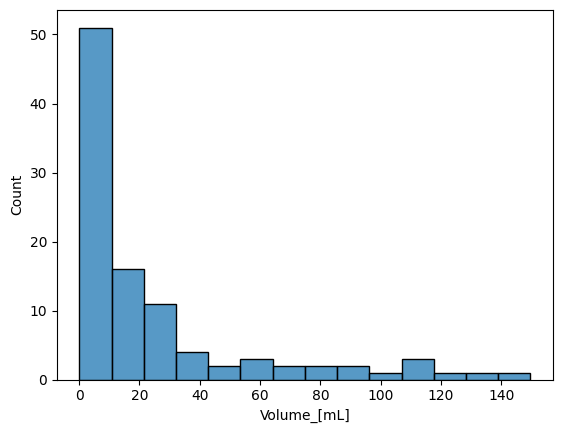

In [11]:
sns.histplot(data=df, x='Volume_[mL]')

Summary as of 08/27/24:

Hemorrhage volumes range from very small (0.122 mL) to VERY large (149.59 mL). 

Somewhat large range in HU [min:28, max:72] with a mean of 54.70. This checks out with the subdural hematoma HU values listed on Wikipedia (in addition to clotted blood values):

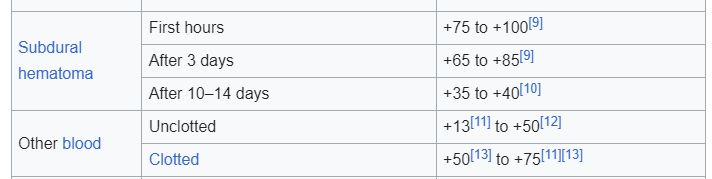

From the above data, there also doesn't seem to be a correlation between hemorrhage volume and mean HU within the hemorrhage. 

Metrics of interest for the future:
1. Hemorrhage type/location
* Volume and HU breakdown could vary by type/location
* Need to either manually classify as EDH/SDH/SAD/IVH/IPH or receive from dataset creators
2. Age
* This dataset doesn't include age information and is likely unavailable
* Assumed age could potentially be extracted from skull size?